This notebook summarize BGC expression per media and creates figures for 'BGC expression among eight media' section under Results. 

In [69]:
import re
import pandas as pd
from matplotlib.lines import Line2D

In [70]:
file_path = '/Users/annasve/Desktop/article_data/output/expression_overall/75th_percentile/bgc_expression_status_detailed.csv'
media_df = pd.read_csv(file_path)

In [71]:
media_df.shape

(46211, 5)

In [72]:
media_df = media_df.drop_duplicates(subset=["Strain", "Medium", "BGC_ID"])

In [73]:
media_df.shape

(35748, 5)

In [74]:
media_df.head()

,Strain,Medium,BGC_ID,Expressed,Frac_High_Expr
0,NBC_01734,DNPM,1.0_terpene_NBC_01734,False,0.0
1,NBC_01734,DNPM,10.0_terpene_NBC_01734,False,0.0
2,NBC_01734,DNPM,11.0_LAP_thioamitides_thiopeptide_NBC_01734,False,0.0
3,NBC_01734,DNPM,12.0_NI-siderophore_NBC_01734,False,0.0
4,NBC_01734,DNPM,13.0_terpene_NBC_01734,False,0.0


In [75]:
media_df["BGC_ID"] = (
    media_df["BGC_ID"]
      .str.replace(".0", "", regex=False)
      .str.replace(", ", "_", regex=False)
)


In [76]:

def extract_bgc_type(bgc_id):
    # Remove everything before the first underscore and after "_NBC" (or final underscore group)
    bgc_id = str(bgc_id)
    match = re.search(r'^[^_]+_([^_]+(?:_[^_]+)*)_NBC', bgc_id)
    if match:
        return match.group(1)
    else:
        # fallback: between first and last underscore
        parts = bgc_id.split('_')
        return '_'.join(parts[1:-1]) if len(parts) > 2 else bgc_id

media_df["bgc_type"] = media_df["BGC_ID"].apply(extract_bgc_type)


# Replace ", " with "_"
media_df["bgc_type"] = media_df["bgc_type"].str.replace(", ", "_", regex=False)


In [77]:
media_df.head()

,Strain,Medium,BGC_ID,Expressed,Frac_High_Expr,bgc_type
0,NBC_01734,DNPM,1_terpene_NBC_01734,False,0.0,terpene
1,NBC_01734,DNPM,10_terpene_NBC_01734,False,0.0,terpene
2,NBC_01734,DNPM,11_LAP_thioamitides_thiopeptide_NBC_01734,False,0.0,LAP_thioamitides_thiopeptide
3,NBC_01734,DNPM,12_NI-siderophore_NBC_01734,False,0.0,NI-siderophore
4,NBC_01734,DNPM,13_terpene_NBC_01734,False,0.0,terpene


In [78]:
# Example
# df["bgc_type"] = ['NRPS_T1PKS', 'T1PKS_NRPS', 'terpene', 'NRPS', 'PKS_NRPS_T1PKS']

def normalize_bgc_type(label):
    """Normalize multi-part BGC type strings so that order doesn't matter."""
    if pd.isna(label):
        return label
    # Split by underscores
    parts = label.split("_")
    # Sort alphabetically and rejoin with underscores
    parts_sorted = sorted(parts)
    return "_".join(parts_sorted)

# Apply normalization
media_df["bgc_type_norm"] = media_df["bgc_type"].apply(normalize_bgc_type)


In [79]:
media_df.head(50)

,Strain,Medium,BGC_ID,Expressed,Frac_High_Expr,bgc_type,bgc_type_norm
0,NBC_01734,DNPM,1_terpene_NBC_01734,False,0.000000,terpene,terpene
1,NBC_01734,DNPM,10_terpene_NBC_01734,False,0.000000,terpene,terpene
2,NBC_01734,DNPM,11_LAP_thioamitides_thiopeptide_NBC_01734,False,0.000000,LAP_thioamitides_thiopeptide,LAP_thioamitides_thiopeptide
3,NBC_01734,DNPM,12_NI-siderophore_NBC_01734,False,0.000000,NI-siderophore,NI-siderophore
4,NBC_01734,DNPM,13_terpene_NBC_01734,False,0.000000,terpene,terpene
5,NBC_01734,DNPM,14_terpene_NBC_01734,True,1.000000,terpene,terpene
6,NBC_01734,DNPM,15_T3PKS_NBC_01734,False,0.000000,T3PKS,T3PKS
7,NBC_01734,DNPM,2_betalactone_NRPS_NBC_01734,False,0.000000,betalactone_NRPS,NRPS_betalactone
8,NBC_01734,DNPM,3_NAPAA_NBC_01734,False,0.000000,NAPAA,NAPAA
9,NBC_01734,DNPM,4_NRP-metallophore_NRPS_RRE-containing_T1PKS_N...,False,0.142857,NRP-metallophore_NRPS_RRE-containing_T1PKS,NRP-metallophore_NRPS_RRE-containing_T1PKS


In [80]:
media_df = media_df[media_df["Medium"] != "All"]

In [81]:
def summarize_media(group):
    expressed_media = group.loc[group["Expressed"], "Medium"].unique()
    if len(expressed_media) == 0:
        return "not_expressed"
    return ", ".join(expressed_media)

bgc_summary = (
    media_df.groupby(["Strain", "BGC_ID", "bgc_type"], as_index=False)
      .apply(lambda g: pd.Series({
          "media_expressed": summarize_media(g)
      }))
)


In [82]:
bgc_summary.head(50)

,Strain,BGC_ID,bgc_type,media_expressed
0,NBC_00001,10_NRPS-like_nucleoside_other_NBC_00001,NRPS-like_nucleoside_other,not_expressed
1,NBC_00001,11_furan_NBC_00001,furan,"ISP2, gluc, gly, malt"
2,NBC_00001,12_NI-siderophore_NBC_00001,NI-siderophore,not_expressed
3,NBC_00001,13_nucleoside_NBC_00001,nucleoside,ISP2
4,NBC_00001,14_terpene_NBC_00001,terpene,SoyM
5,NBC_00001,15_furan_NBC_00001,furan,not_expressed
6,NBC_00001,16_T2PKS_thioamide-NRP_NBC_00001,T2PKS_thioamide-NRP,not_expressed
7,NBC_00001,17_thioamitides_NBC_00001,thioamitides,"DNPM, ISP2"
8,NBC_00001,18_NI-siderophore_NBC_00001,NI-siderophore,"DNPM, ISP2, SoyM, gluc, malt"
9,NBC_00001,19_melanin_NBC_00001,melanin,not_expressed


In [83]:
bgc_summary["Strain"].nunique()


132

In [84]:
bgc_summary.to_excel('bgc_expression_antismash.xlsx')

In [85]:
#n_types = media_df["bgc_type_norm"].nunique()
#n_types

In [96]:
# Assuming df["bgc_type_norm"] already exists from the previous normalization
media_df["bgc_type_final"] = media_df["bgc_type_norm"].apply(
    lambda x: "hybrid" if isinstance(x, str) and x.count("_") > 0 else x
)

In [97]:
n_types = media_df["bgc_type_final"].nunique()
n_types

50

In [98]:
unique_types = sorted(media_df["bgc_type_final"].unique())

In [105]:
# Define the "Other" category list
other_types = [
    'CDPS','LAP','NAGGN','NAPAA','amglyccycl','aminopolycarboxylic-acid',
    'arylpolyene','betalactone','blactam','butyrolactone','crocagin','cyanobactin',
    'ectoine','furan','guanidinotides','hserlactone','indole','lassopeptide',
    'linaridin','melanin','methanobactin','nucleoside','other','phenazine',
    'phosphonate','ranthipeptide','redox-cofactor','sactipeptide','thioamide-NRP',
    'thioamitides','thiopeptide','transAT-PKS', 'RRE-containing', 'oligosaccharide'
]

# Normalize to lowercase for matching, but keep the original capitalization
def standardize_bgc_type(bgc_type):
    if pd.isna(bgc_type):
        return bgc_type
    
    bgc_type_stripped = str(bgc_type).strip()
    bgc_lower = bgc_type_stripped.lower()

    # Group all lanthipeptide-containing into "lanthipeptide"
    if "lanthipeptide" in bgc_lower:
        return "lanthipeptide"

    # If it's one of the predefined "other" types
    elif bgc_lower in [t.lower() for t in other_types]:
        return "other"

    # Otherwise, keep the original capitalization
    else:
        return bgc_type_stripped

# Apply the transformation
media_df["bgc_type_final"] = media_df["bgc_type_final"].apply(standardize_bgc_type)


In [106]:
n_types = media_df["bgc_type_final"].nunique()
n_types

14

In [107]:
unique_types = sorted(media_df["bgc_type_final"].unique())

In [108]:
unique_types

['NI-siderophore',
 'NRPS',
 'NRPS-like',
 'PKS-like',
 'RiPP-like',
 'T1PKS',
 'T2PKS',
 'T3PKS',
 'hglE-KS',
 'hybrid',
 'ladderane',
 'lanthipeptide',
 'other',
 'terpene']

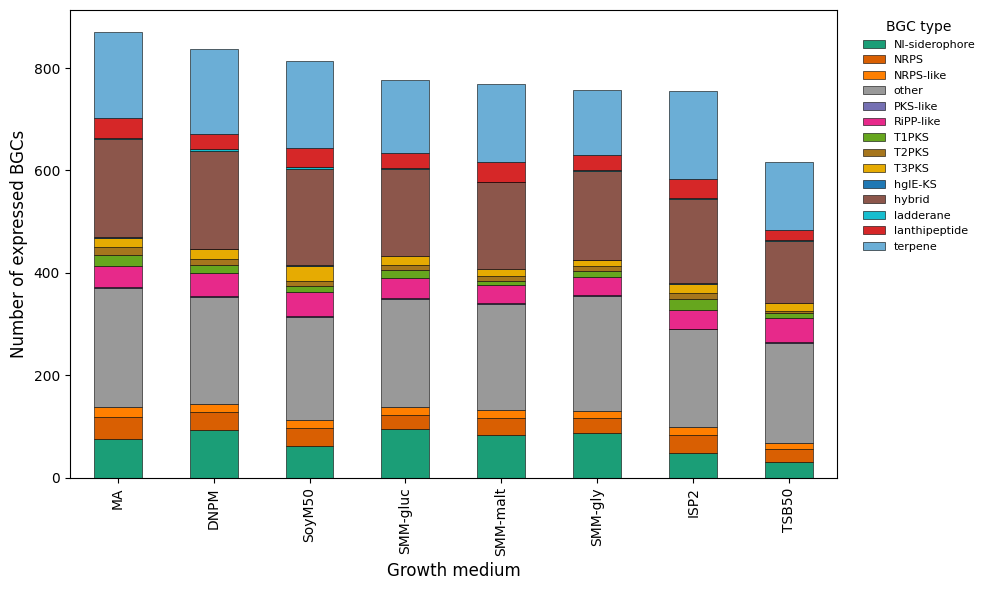

In [109]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Define custom modern, color-blind–friendly palette ---
bgc_colors = {
    'NI-siderophore':   '#1b9e77',  # teal-green
    'NRPS':             '#d95f02',  # orange
    'NRPS-like':        '#ff7f00',  # bright orange
    'other':            '#999999',  # gray
    'PKS-like':         '#7570b3',  # purple
    'RiPP-like':        '#e7298a',  # pink-magenta
    'T1PKS':            '#66a61e',  # olive green
    'T2PKS':            '#a6761d',  # brown
    'T3PKS':            '#e6ab02',  # gold-yellow
    'hglE-KS':          '#1f78b4',  # strong blue
    'hybrid':           '#8c564b',  # warm beige
    'ladderane':        '#17becf',  # cyan
    'lanthipeptide':    '#d62728',  # red
    'oligosaccharide':  '#bc80bd',  # lilac
    'terpene':          '#6baed6'   # light blue
}

# --- Filter only expressed BGCs and drop 'All' medium ---
df_expr = media_df[(media_df["Expressed"] == True) & (media_df["Medium"] != "All")].copy()

# --- Rename media for clarity ---
medium_rename = {
    "SoyM": "SoyM50",
    "TSB": "TSB50",
    "gluc": "SMM-gluc",
    "gly": "SMM-gly",
    "malt": "SMM-malt"
}
df_expr["Medium"] = df_expr["Medium"].replace(medium_rename)

# --- Group by Medium and BGC type ---
bgc_counts = (
    df_expr.groupby(["Medium", "bgc_type_final"])
    .size()
    .reset_index(name="Count")
)

# --- Pivot to wide format for stacked plotting ---
bgc_pivot = bgc_counts.pivot(index="Medium", columns="bgc_type_final", values="Count").fillna(0)

# --- Sort media by total number of expressed clusters ---
bgc_pivot = bgc_pivot.loc[bgc_pivot.sum(axis=1).sort_values(ascending=False).index]

# --- Ensure consistent column order ---
ordered_cols = [c for c in bgc_colors.keys() if c in bgc_pivot.columns]
bgc_pivot = bgc_pivot[ordered_cols]

# --- Plot ---
fig, ax = plt.subplots(figsize=(10,6))
bgc_pivot.plot(
    kind="bar",
    stacked=True,
    color=[bgc_colors[c] for c in bgc_pivot.columns],
    edgecolor="black",
    linewidth=0.4,
    ax=ax
)

# --- Customize aesthetics ---
ax.set_xlabel("Growth medium", fontsize=12)
ax.set_ylabel("Number of expressed BGCs", fontsize=12)
# ax.set_title("Composition of expressed BGCs across media", fontsize=13, pad=15)

ax.legend(
    title="BGC type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8,
    title_fontsize=10,
    frameon=False
)

plt.tight_layout()
plt.savefig("bgc_expression_overall.png", dpi=400)
plt.show()


In [110]:
bgc_pivot

bgc_type_final,NI-siderophore,NRPS,NRPS-like,other,PKS-like,RiPP-like,T1PKS,T2PKS,T3PKS,hglE-KS,hybrid,ladderane,lanthipeptide,terpene
Medium,,,,,,,,,,,,,,
MA,76.0,43.0,18.0,233.0,2.0,42.0,20.0,16.0,19.0,1.0,192.0,2.0,39.0,167.0
DNPM,93.0,36.0,14.0,210.0,1.0,46.0,16.0,12.0,18.0,1.0,192.0,3.0,29.0,166.0
SoyM50,62.0,35.0,15.0,201.0,2.0,47.0,13.0,10.0,28.0,3.0,187.0,4.0,37.0,169.0
SMM-gluc,95.0,27.0,15.0,211.0,2.0,39.0,16.0,11.0,16.0,0.0,171.0,1.0,30.0,142.0
SMM-malt,83.0,34.0,15.0,207.0,2.0,36.0,8.0,9.0,13.0,0.0,170.0,1.0,38.0,152.0
SMM-gly,87.0,29.0,15.0,224.0,1.0,36.0,12.0,10.0,11.0,1.0,173.0,2.0,29.0,127.0
ISP2,48.0,35.0,15.0,192.0,1.0,37.0,20.0,13.0,18.0,1.0,165.0,2.0,37.0,171.0
TSB50,31.0,25.0,12.0,195.0,1.0,48.0,10.0,4.0,15.0,0.0,122.0,2.0,18.0,133.0


In [111]:
bgc_pivot.to_excel('bgc_expression_type_media.xlsx')

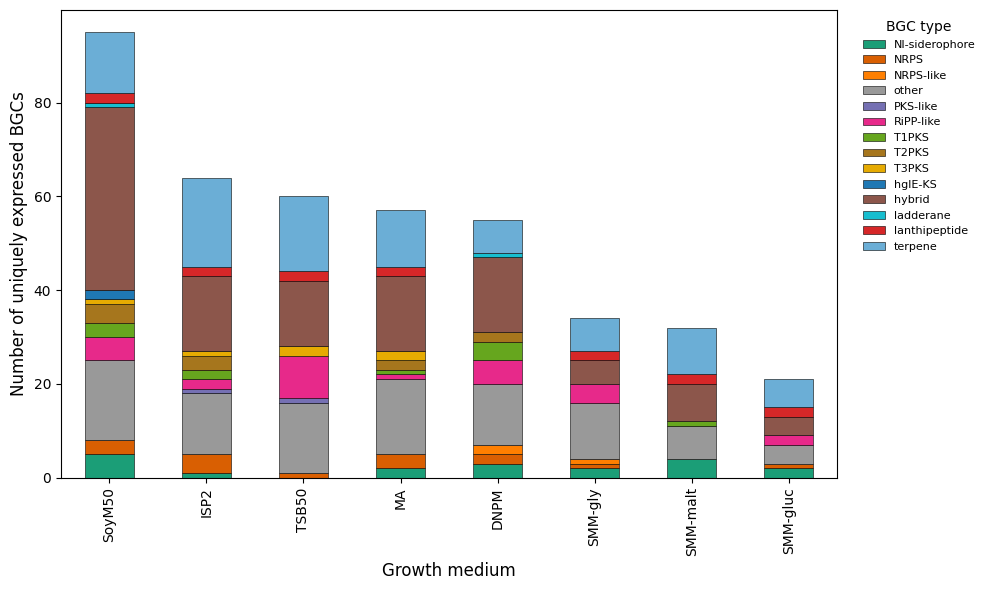


🧬 Medium-specific BGCs per medium:
Medium
SoyM50      95
ISP2        64
TSB50       60
MA          57
DNPM        55
SMM-gly     34
SMM-malt    32
SMM-gluc    21
Name: Count, dtype: int64


In [112]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Define your custom color palette ---
bgc_colors = {
    'NI-siderophore':   '#1b9e77',
    'NRPS':             '#d95f02',
    'NRPS-like':        '#ff7f00',
    'other':            '#999999',
    'PKS-like':         '#7570b3',
    'RiPP-like':        '#e7298a',
    'T1PKS':            '#66a61e',
    'T2PKS':            '#a6761d',
    'T3PKS':            '#e6ab02',
    'hglE-KS':          '#1f78b4',
    'hybrid':           '#8c564b',
    'ladderane':        '#17becf',
    'lanthipeptide':    '#d62728',
    'oligosaccharide':  '#bc80bd',
    'terpene':          '#6baed6'
}

# --- Filter valid media (exclude 'All') ---
df = media_df[media_df["Medium"] != "All"].copy()

# --- Step 1: Count how many media each (Strain × BGC_ID) is expressed in ---
bgc_media_summary = (
    df.groupby(["Strain", "BGC_ID"], as_index=False)
    .agg(
        n_media_expressed=("Expressed", "sum"),
        bgc_type=("bgc_type_final", "first")
    )
)

# --- Step 2: Keep only BGCs expressed in exactly one medium ---
unique_bgcs = bgc_media_summary[bgc_media_summary["n_media_expressed"] == 1]

# --- Step 3: Identify which medium each unique BGC is expressed in ---
unique_expr = (
    df.merge(unique_bgcs[["Strain", "BGC_ID"]], on=["Strain", "BGC_ID"])
)
unique_expr = unique_expr[unique_expr["Expressed"] == True]

# --- Step 4: Count per medium × type ---
bgc_unique_counts = (
    unique_expr.groupby(["Medium", "bgc_type_final"])
    .size()
    .reset_index(name="Count")
)

# --- Rename media for figure ---
medium_rename = {
    "SoyM": "SoyM50",
    "TSB": "TSB50",
    "gluc": "SMM-gluc",
    "gly": "SMM-gly",
    "malt": "SMM-malt"
}
bgc_unique_counts["Medium"] = bgc_unique_counts["Medium"].replace(medium_rename)

# --- Step 5: Pivot for stacked barplot ---
bgc_unique_pivot = (
    bgc_unique_counts
    .pivot(index="Medium", columns="bgc_type_final", values="Count")
    .fillna(0)
)

# --- Sort media by total unique BGCs ---
bgc_unique_pivot = bgc_unique_pivot.loc[
    bgc_unique_pivot.sum(axis=1).sort_values(ascending=False).index
]

# --- Ensure consistent column order for colors ---
ordered_cols = [c for c in bgc_colors.keys() if c in bgc_unique_pivot.columns]
bgc_unique_pivot = bgc_unique_pivot[ordered_cols]

# --- Step 6: Plot ---
fig, ax = plt.subplots(figsize=(10, 6))
bgc_unique_pivot.plot(
    kind="bar",
    stacked=True,
    color=[bgc_colors[c] for c in bgc_unique_pivot.columns],
    edgecolor="black",
    linewidth=0.4,
    ax=ax
)

ax.set_xlabel("Growth medium", fontsize=12)
ax.set_ylabel("Number of uniquely expressed BGCs", fontsize=12)
#ax.set_title("Medium-specific expression of BGC types", fontsize=13, pad=15)

ax.legend(
    title="BGC type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8,
    title_fontsize=10,
    frameon=False
)

plt.tight_layout()
plt.savefig("bgc_expression_specific_media_activation.png", dpi=400)
plt.show()

# --- Step 7: Optional summary printout ---
summary_table = (
    bgc_unique_counts.groupby("Medium")["Count"]
    .sum()
    .sort_values(ascending=False)
)
print("\n🧬 Medium-specific BGCs per medium:")
print(summary_table)


In [113]:
bgc_unique_pivot

bgc_type_final,NI-siderophore,NRPS,NRPS-like,other,PKS-like,RiPP-like,T1PKS,T2PKS,T3PKS,hglE-KS,hybrid,ladderane,lanthipeptide,terpene
Medium,,,,,,,,,,,,,,
SoyM50,5.0,3.0,0.0,17.0,0.0,5.0,3.0,4.0,1.0,2.0,39.0,1.0,2.0,13.0
ISP2,1.0,4.0,0.0,13.0,1.0,2.0,2.0,3.0,1.0,0.0,16.0,0.0,2.0,19.0
TSB50,0.0,1.0,0.0,15.0,1.0,9.0,0.0,0.0,2.0,0.0,14.0,0.0,2.0,16.0
MA,2.0,3.0,0.0,16.0,0.0,1.0,1.0,2.0,2.0,0.0,16.0,0.0,2.0,12.0
DNPM,3.0,2.0,2.0,13.0,0.0,5.0,4.0,2.0,0.0,0.0,16.0,1.0,0.0,7.0
SMM-gly,2.0,1.0,1.0,12.0,0.0,4.0,0.0,0.0,0.0,0.0,5.0,0.0,2.0,7.0
SMM-malt,4.0,0.0,0.0,7.0,0.0,0.0,1.0,0.0,0.0,0.0,8.0,0.0,2.0,10.0
SMM-gluc,2.0,1.0,0.0,4.0,0.0,2.0,0.0,0.0,0.0,0.0,4.0,0.0,2.0,6.0


In [114]:
# --- List all unique BGCs per medium and their types ---
unique_bgcs_by_medium = (
    unique_expr[["Strain", "Medium", "BGC_ID", "bgc_type_final"]]
    .sort_values(["Medium", "Strain", "BGC_ID"])
)

# Display a preview in the console
print("\n🧬 Example: unique BGCs per medium (first 20 rows):")
print(unique_bgcs_by_medium.head(20))

# --- Save full table to CSV for inspection ---
unique_bgcs_by_medium.to_csv("unique_bgcs_per_medium.csv", index=False)

# --- Optional summary per medium and type ---
summary_by_type = (
    unique_bgcs_by_medium
    .groupby(["Medium", "bgc_type_final"])
    .size()
    .reset_index(name="Count")
    .sort_values(["Medium", "Count"], ascending=[True, False])
)

print("\n📊 Count of unique BGCs per medium × type:")
print(summary_by_type)

# --- Save this summary too ---
summary_by_type.to_csv("unique_bgcs_summary_by_medium_type.csv", index=False)



🧬 Example: unique BGCs per medium (first 20 rows):
         Strain Medium                                      BGC_ID  \
1877  NBC_00012   DNPM                        18_terpene_NBC_00012   
1893  NBC_00012   DNPM                23_NRPS-like_T1PKS_NBC_00012   
2946  NBC_00111   DNPM                  15_butyrolactone_NBC_00111   
872   NBC_00122   DNPM  10_CDPS_phenazine_PKS-like_T1PKS_NBC_00122   
888   NBC_00122   DNPM                  12_NRPS_PKS-like_NBC_00122   
904   NBC_00122   DNPM                        18_melanin_NBC_00122   
2277  NBC_00169   DNPM                        13_ectoine_NBC_00169   
2285  NBC_00169   DNPM                 15_NI-siderophore_NBC_00169   
944   NBC_00185   DNPM                 14_NI-siderophore_NBC_00185   
2173  NBC_00337   DNPM                      31_CDPS_NRPS_NBC_00337   
3026  NBC_00400   DNPM                       7_RiPP-like_NBC_00400   
3274  NBC_00439   DNPM                     2_5_RiPP-like_NBC_00439   
3290  NBC_00439   DNPM                

In [115]:
summary_by_type

,Medium,bgc_type_final,Count
6,DNPM,hybrid,16
8,DNPM,other,13
9,DNPM,terpene,7
3,DNPM,RiPP-like,5
4,DNPM,T1PKS,4
...,...,...,...
68,malt,hybrid,8
70,malt,other,7
66,malt,NI-siderophore,4
69,malt,lanthipeptide,2


### Heatmap of percentage of expressed BGCs per media

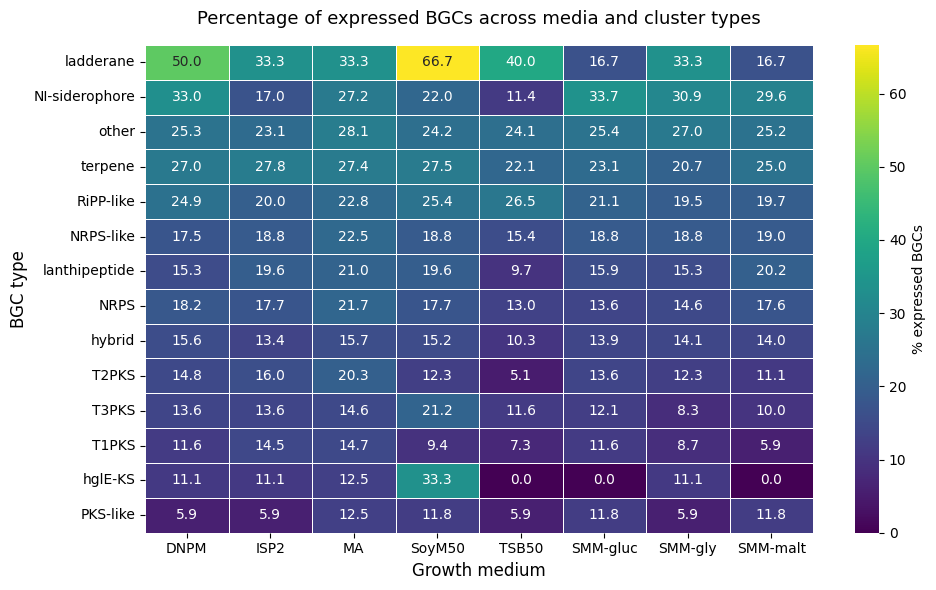

In [116]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Copy and relabel media names for consistency with figures ---
media_labels = {
    "SoyM": "SoyM50",
    "TSB": "TSB50",
    "gluc": "SMM-gluc",
    "gly": "SMM-gly",
    "malt": "SMM-malt"
}

df = media_df.copy()
df["Medium"] = df["Medium"].replace(media_labels)
df = df[df["Medium"] != "All"]
df["Expressed"] = df["Expressed"].astype(bool)
df["Strain_BGC"] = df["Strain"].astype(str) + "_" + df["BGC_ID"].astype(str)

# --- Calculate % expressed per medium × BGC type ---
summary = (
    df.groupby(["Medium", "bgc_type_final"])
    .agg(
        total_clusters=("Strain_BGC", "nunique"),
        expressed_clusters=("Expressed", lambda x: df.loc[x.index, "Strain_BGC"][x].nunique())
    )
    .reset_index()
)

summary["Pct_Expressed"] = (summary["expressed_clusters"] / summary["total_clusters"]) * 100

# --- Pivot for heatmap ---
heatmap_df = summary.pivot(index="bgc_type_final", columns="Medium", values="Pct_Expressed").fillna(0)
heatmap_df = heatmap_df.loc[heatmap_df.mean(axis=1).sort_values(ascending=False).index]

# --- Order media ---
media_order = ["DNPM", "ISP2", "MA", "SoyM50", "TSB50", "SMM-gluc", "SMM-gly", "SMM-malt"]
heatmap_df = heatmap_df[[m for m in media_order if m in heatmap_df.columns]]

# --- Plot ---
plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_df,
    cmap="viridis",
    linewidths=0.5,
    annot=True,
    fmt=".1f",
    cbar_kws={"label": "% expressed BGCs"},
)

plt.title("Percentage of expressed BGCs across media and cluster types", fontsize=13, pad=15)
plt.xlabel("Growth medium", fontsize=12)
plt.ylabel("BGC type", fontsize=12)

plt.tight_layout()
plt.savefig("figure_heatmap_BGC_expression.png", dpi=400)
plt.show()

heatmap_df.to_csv("heatmap_expression_data.csv")


### Medium overlap analysis

<Figure size 1000x1000 with 0 Axes>

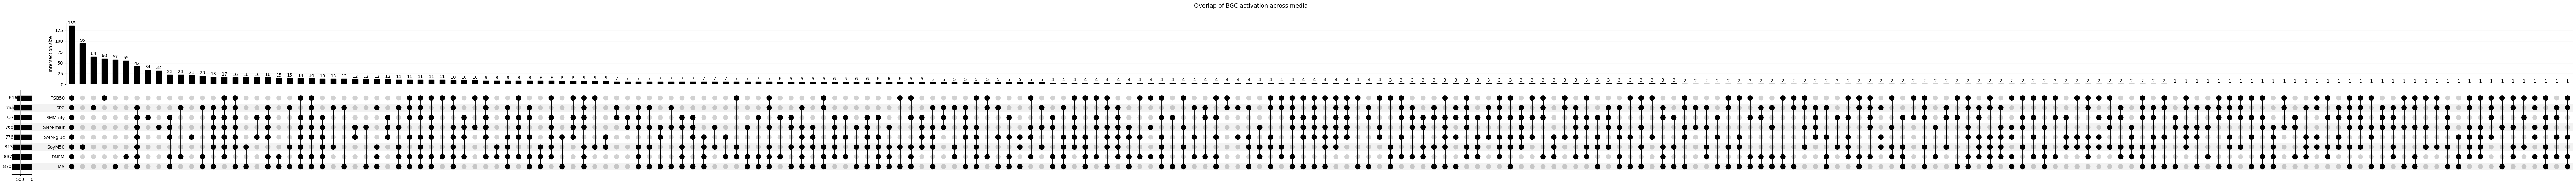

In [117]:
from upsetplot import UpSet, from_memberships
import matplotlib.pyplot as plt

# Create mapping per (Strain, BGC_ID)
bgc_activity = (
    df[df["Expressed"] == True]
    .groupby(['Strain', 'BGC_ID'])["Medium"]
    .unique()
    .reset_index()
)

# Prepare membership list
memberships = bgc_activity["Medium"].apply(lambda x: list(x))
data_upset = from_memberships(memberships)

# Plot UpSet (top combinations only)
plt.figure(figsize=(10, 10))
UpSet(data_upset, subset_size='count', show_counts=True, sort_by='cardinality').plot()
plt.suptitle("Overlap of BGC activation across media", fontsize=13)
plt.savefig("figure_upset_BGC_overlap.png", dpi=400)
plt.show()


In [118]:
bgc_activity

,Strain,BGC_ID,Medium
0,NBC_00001,11_furan_NBC_00001,"[ISP2, SMM-gluc, SMM-gly, SMM-malt]"
1,NBC_00001,13_nucleoside_NBC_00001,[ISP2]
2,NBC_00001,14_terpene_NBC_00001,[SoyM50]
3,NBC_00001,17_thioamitides_NBC_00001,"[DNPM, ISP2]"
4,NBC_00001,18_NI-siderophore_NBC_00001,"[DNPM, ISP2, SoyM50, SMM-gluc, SMM-malt]"
...,...,...,...
1664,NBC_01815,21_RiPP-like_NBC_01815,[SoyM50]
1665,NBC_01815,4_ectoine_NBC_01815,"[SMM-gly, SMM-malt]"
1666,NBC_01815,5_NI-siderophore_NBC_01815,"[SMM-gluc, SMM-gly, SMM-malt]"
1667,NBC_01815,7_RiPP-like_NBC_01815,"[DNPM, SoyM50, TSB50]"


In [119]:
media_df.columns

Index(['Strain', 'Medium', 'BGC_ID', 'Expressed', 'Frac_High_Expr', 'bgc_type',
       'bgc_type_norm', 'bgc_type_final'],
      dtype='object')

In [120]:
media_df

,Strain,Medium,BGC_ID,Expressed,Frac_High_Expr,bgc_type,bgc_type_norm,bgc_type_final
0,NBC_01734,DNPM,1_terpene_NBC_01734,False,0.0,terpene,terpene,terpene
1,NBC_01734,DNPM,10_terpene_NBC_01734,False,0.0,terpene,terpene,terpene
2,NBC_01734,DNPM,11_LAP_thioamitides_thiopeptide_NBC_01734,False,0.0,LAP_thioamitides_thiopeptide,LAP_thioamitides_thiopeptide,hybrid
3,NBC_01734,DNPM,12_NI-siderophore_NBC_01734,False,0.0,NI-siderophore,NI-siderophore,NI-siderophore
4,NBC_01734,DNPM,13_terpene_NBC_01734,False,0.0,terpene,terpene,terpene
...,...,...,...,...,...,...,...,...
46169,NBC_01770,malt,5_ectoine_NBC_01770,False,0.0,ectoine,ectoine,other
46170,NBC_01770,malt,6_T3PKS_NBC_01770,False,0.0,T3PKS,T3PKS,T3PKS
46171,NBC_01770,malt,7_melanin_NBC_01770,False,0.0,melanin,melanin,other
46172,NBC_01770,malt,8_lanthipeptide-class-v_LAP_NBC_01770,False,0.0,lanthipeptide-class-v_LAP,LAP_lanthipeptide-class-v,hybrid


In [121]:
import pandas as pd

# Assuming your dataframe is named media_df
df = media_df.copy()

# Drop the "All" medium
df = df[df["Medium"] != "All"].copy()

# Ensure Expressed is boolean
df["Expressed"] = df["Expressed"].astype(bool)

# Define unique BGC identifier
df["Strain_BGC"] = df["Strain"].astype(str) + "_" + df["BGC_ID"].astype(str)

# Find which unique BGCs are expressed in at least one medium
expressed_bgcs = (
    df.groupby("Strain_BGC")["Expressed"]
    .any()  # True if expressed in any medium
    .reset_index()
)

# Count expressed and total
n_expressed = expressed_bgcs["Expressed"].sum()
n_total = expressed_bgcs.shape[0]
pct_expressed = (n_expressed / n_total) * 100

print(f"🧬 Total unique BGCs (by strain): {n_total}")
print(f"✅ Expressed in at least one medium: {n_expressed} ({pct_expressed:.1f}%)")
print(f"🚫 Not expressed: {n_total - n_expressed}")


🧬 Total unique BGCs (by strain): 3993
✅ Expressed in at least one medium: 1669 (41.8%)
🚫 Not expressed: 2324


In [122]:
from scipy.stats import fisher_exact
import numpy as np

results = []
for medium in df["Medium"].unique():
    for bgc_type in df["bgc_type_final"].unique():
        subset = df[(df["Medium"] == medium)]
        a = subset[(subset["bgc_type_final"] == bgc_type) & (subset["Expressed"])].shape[0]
        b = subset[(subset["bgc_type_final"] == bgc_type) & (~subset["Expressed"])].shape[0]
        c = subset[(subset["bgc_type_final"] != bgc_type) & (subset["Expressed"])].shape[0]
        d = subset[(subset["bgc_type_final"] != bgc_type) & (~subset["Expressed"])].shape[0]
        table = np.array([[a, b], [c, d]])
        odds, p = fisher_exact(table)
        results.append([medium, bgc_type, a, b, c, d, odds, p])

fisher_df = pd.DataFrame(results, columns=["Medium", "BGC_Type", "a", "b", "c", "d", "Odds_Ratio", "P_Value"])
fisher_df["FDR"] = fisher_df.groupby("Medium")["P_Value"].transform(lambda x: x * len(x) / (np.arange(1, len(x)+1)))
fisher_df.to_csv("BGC_enrichment_by_medium.csv", index=False)


In [123]:
fisher_df.head(50)

,Medium,BGC_Type,a,b,c,d,Odds_Ratio,P_Value,FDR
0,DNPM,terpene,166,449,671,2707,1.491515,1.018237e-04,1.425532e-03
1,DNPM,hybrid,192,1038,645,2118,0.607393,1.972896e-08,1.381027e-07
2,DNPM,NI-siderophore,93,189,744,2967,1.962302,9.876962e-07,4.609249e-06
3,DNPM,T3PKS,18,114,819,3042,0.586466,3.825019e-02,1.338757e-01
4,DNPM,other,210,621,627,2535,1.367219,7.903709e-04,2.213039e-03
5,DNPM,lanthipeptide,29,160,808,2996,0.672061,5.437340e-02,1.268713e-01
6,DNPM,T2PKS,12,69,825,3087,0.650751,2.136340e-01,4.272680e-01
7,DNPM,ladderane,3,3,834,3153,3.780576,1.108940e-01,1.940645e-01
8,DNPM,NRPS-like,14,66,823,3090,0.796421,4.908311e-01,7.635151e-01
9,DNPM,T1PKS,16,122,821,3034,0.484655,5.360053e-03,7.504074e-03


/var/folders/zm/bd67fqqd1cg4ycfsvq5v2x_h0000gp/T/ipykernel_15137/2193862035.py:150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


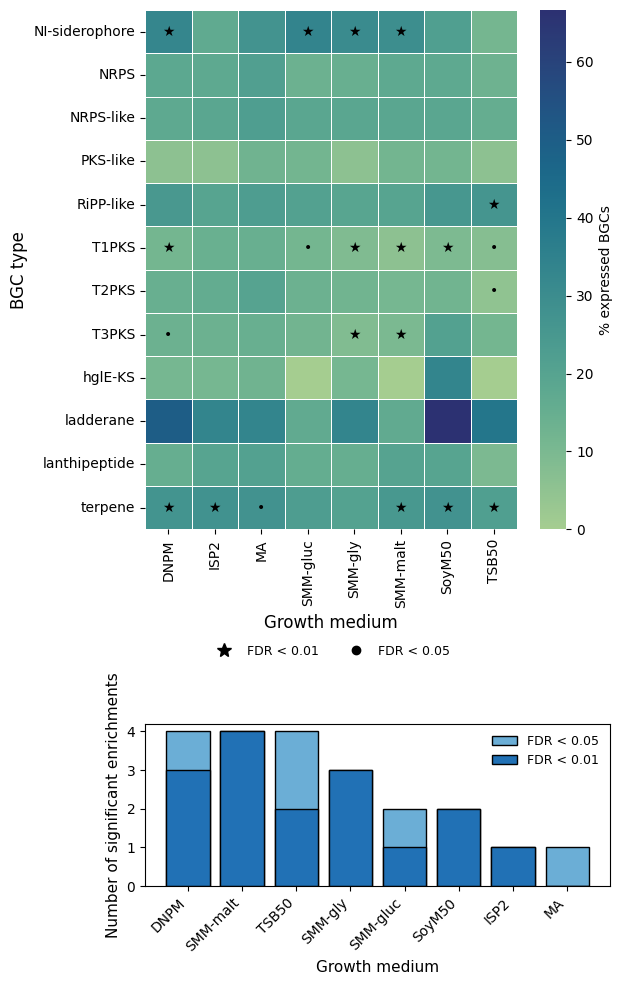

In [125]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# ----------------------------------------------------
# Data prep
# ----------------------------------------------------
df = media_df.copy()
df = df[df["Medium"] != "All"].copy()
df["Expressed"] = df["Expressed"].astype(bool)
df["Strain_BGC"] = df["Strain"].astype(str) + "_" + df["BGC_ID"].astype(str)

# Publication-friendly naming
media_labels = {
    "SoyM": "SoyM50",
    "TSB": "TSB50",
    "gluc": "SMM-gluc",
    "gly": "SMM-gly",
    "malt": "SMM-malt"
}
df["Medium"] = df["Medium"].replace(media_labels)

# Remove broad/mixed BGC categories from figure
df = df[~df["bgc_type_final"].isin(["hybrid", "Hybrid", "other", "Other"])].copy()

# ----------------------------------------------------
# % expressed per medium × type
# ----------------------------------------------------
summary = (
    df.groupby(["Medium", "bgc_type_final"])
    .agg(
        total_clusters=("Strain_BGC", "nunique"),
        expressed_clusters=("Strain_BGC", lambda x: df.loc[x.index, "Strain_BGC"][df.loc[x.index, "Expressed"]].nunique())
    )
    .reset_index()
)
summary["Pct_Expressed"] = (summary["expressed_clusters"] / summary["total_clusters"]) * 100
heatmap_df = summary.pivot(index="bgc_type_final", columns="Medium", values="Pct_Expressed").fillna(0)

# ----------------------------------------------------
# Fisher enrichment tests
# ----------------------------------------------------
results = []
for medium in df["Medium"].unique():
    for bgc_type in df["bgc_type_final"].unique():
        subset = df[df["Medium"] == medium]
        a = subset[(subset["bgc_type_final"] == bgc_type) & (subset["Expressed"])].shape[0]
        b = subset[(subset["bgc_type_final"] == bgc_type) & (~subset["Expressed"])].shape[0]
        c = subset[(subset["bgc_type_final"] != bgc_type) & (subset["Expressed"])].shape[0]
        d = subset[(subset["bgc_type_final"] != bgc_type) & (~subset["Expressed"])].shape[0]
        if (a + b + c + d) == 0:
            continue
        table = np.array([[a, b], [c, d]])
        odds, p = fisher_exact(table)
        results.append([medium, bgc_type, odds, p])

fisher_df = pd.DataFrame(results, columns=["Medium", "BGC_Type", "Odds_Ratio", "P_Value"])
fisher_df["FDR"] = multipletests(fisher_df["P_Value"], method="fdr_bh")[1]

# ----------------------------------------------------
# Annotate significance (black markers)
# ----------------------------------------------------
annot_df = pd.DataFrame("", index=heatmap_df.index, columns=heatmap_df.columns)
for _, row in fisher_df.iterrows():
    if row["FDR"] < 0.01:
        annot_df.loc[row["BGC_Type"], row["Medium"]] = "★"
    elif row["FDR"] < 0.05:
        annot_df.loc[row["BGC_Type"], row["Medium"]] = "•"

# ----------------------------------------------------
# Count significant enrichments per medium
# ----------------------------------------------------
sig_summary = (
    fisher_df
    .assign(sig05=lambda x: x["FDR"] < 0.05,
            sig01=lambda x: x["FDR"] < 0.01)
    .groupby("Medium")
    .agg(
        FDR_05=("sig05", "sum"),
        FDR_01=("sig01", "sum")
    )
    .reset_index()
    .sort_values("FDR_05", ascending=False)
)

# ----------------------------------------------------
# Combined plot layout (barplot below heatmap)
# ----------------------------------------------------
fig = plt.figure(figsize=(6, 12))
gs = GridSpec(2, 1, height_ratios=[3.2, 1.0], hspace=0.57)

# --- Heatmap ---
ax1 = fig.add_subplot(gs[0])
sns.heatmap(
    heatmap_df,
    cmap="crest",
    linewidths=0.5,
    annot=annot_df,
    fmt="",
    cbar_kws={"label": "% expressed BGCs"},
    annot_kws={"fontsize": 10, "color": "black", "ha": "center", "va": "center"},
    ax=ax1
)
#ax1.set_title("BGC expression across media and cluster types", fontsize=13, pad=15)
ax1.set_xlabel("Growth medium", fontsize=12)
ax1.set_ylabel("BGC type", fontsize=12)

from matplotlib.lines import Line2D

# --- Custom legend for enrichment markers ---
legend_elements = [
    Line2D([0], [0], marker='*', color='black', linestyle='None',
           markersize=10, label='FDR < 0.01'),
    Line2D([0], [0], marker='o', color='black', linestyle='None',
           markersize=6, label='FDR < 0.05')
]

# Place legend BELOW heatmap, not cut off by tight_layout
ax1.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.20),  # move slightly below heatmap
    ncol=2,
    frameon=False,
    fontsize=9
)

# Adjust figure layout to preserve space for the legend
plt.subplots_adjust(bottom=0.15)


# --- Barplot ---
ax2 = fig.add_subplot(gs[1])
ax2.bar(sig_summary["Medium"], sig_summary["FDR_05"], color="#6baed6", edgecolor="black", label="FDR < 0.05")
ax2.bar(sig_summary["Medium"], sig_summary["FDR_01"], color="#2171b5", edgecolor="black", label="FDR < 0.01")

ax2.set_xlabel("Growth medium", fontsize=11)
ax2.set_ylabel("Number of significant enrichments", fontsize=11)
#ax2.set_title("Media with the most specific BGC activations", fontsize=12, pad=5)
ax2.legend(frameon=False, fontsize=9, loc="upper right")

# ✅ Rotate x-tick labels
plt.setp(ax2.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig("figure_BGC_heatmap_with_barplot_rotated.png", dpi=400, bbox_inches='tight')
plt.show()


In [126]:
file_path = '/Users/annasve/Desktop/article_data/output/expression_overall/bgc_expression_per_strain_both.csv'

In [127]:
df = pd.read_csv(file_path)

In [128]:
import pandas as pd

# assuming your dataframe is called df
df["pct_expr_75"] = df["BGCs_expressed_75th"] / df["Total_BGCs"] * 100
df["pct_expr_50"] = df["BGCs_expressed_50th"] / df["Total_BGCs"] * 100

def summary_stats(series):
    return {
        "median": series.median(),
        "Q1": series.quantile(0.25),
        "Q3": series.quantile(0.75),
        "IQR": series.quantile(0.75) - series.quantile(0.25),
        "min": series.min(),
        "max": series.max(),
        "range": series.max() - series.min()
    }

stats_75 = summary_stats(df["pct_expr_75"])
stats_50 = summary_stats(df["pct_expr_50"])

summary_df = pd.DataFrame([stats_75, stats_50],
                          index=["75th_percentile", "50th_percentile"])

summary_df


,median,Q1,Q3,IQR,min,max,range
75th_percentile,43.534002,36.777920,50.00000,13.222080,19.230769,70.0,50.769231
50th_percentile,62.678571,57.142857,69.86532,12.722463,26.923077,95.0,68.076923


In [129]:
# percentages
df["pct_expr_75"] = df["BGCs_expressed_75th"] / df["Total_BGCs"]
df["pct_expr_50"] = df["BGCs_expressed_50th"] / df["Total_BGCs"]

# number of strains exceeding 50%
n_75 = (df["pct_expr_75"] > 0.5).sum()
n_50 = (df["pct_expr_50"] > 0.5).sum()

n_75, n_50


(29, 118)